## Handwritten English Character Recognition Using Classical Vision & Machine Learning

## Problem Statement 1
Develop a classical computer-vision-based recognition system for handwritten English letters (A–Z) using the EMNIST Letters dataset. The system uses low-level and mid-level feature extraction with classical ML models.

## Import Required Libraries

In [ ]:
%pip install opencv-python matplotlib tensorflow tensorflow-datasets scikit-learn scikit-image

import numpy as np                 # Numerical operations and array handling
import cv2                         # Image processing (OpenCV)
import matplotlib.pyplot as plt    # Visualisation of images and plots

import tensorflow as tf            # Deep learning framework
import tensorflow_datasets as tfds # Easy access to standard datasets

from sklearn.model_selection import train_test_split   # Splitting data into train and test sets
from sklearn.preprocessing import StandardScaler       # Feature scaling for ML models

from sklearn.neighbors import KNeighborsClassifier     # KNN classifier
from sklearn.svm import SVC                             # Support Vector Machine
from sklearn.ensemble import RandomForestClassifier     # Random Forest classifier
from sklearn.linear_model import LogisticRegression     # Logistic Regression model

from sklearn.metrics import (
    accuracy_score,            # Measures overall accuracy
    f1_score,                  # Balances precision and recall
    confusion_matrix,          # Creates confusion matrix
    ConfusionMatrixDisplay     # Visual display of confusion matrix
)

from skimage.feature import (
    local_binary_pattern,      # Texture feature extraction
    hog                        # Histogram of Oriented Gradients
)

import warnings                # Handling and suppressing warnings
import os                      # File and directory operations


# Suppress all warnings for cleaner output during execution
warnings.filterwarnings("ignore")

print("All required libraries imported successfully")

All required libraries imported successfully


## Data Acquisition

In [ ]:
print("Loading EMNIST Letters dataset...")

# Load the EMNIST Letters dataset, splitting it into training and test sets.
# `as_supervised=True` returns data as (image, label) tuples.
(ds_train, ds_test), info = tfds.load(
    'emnist/letters',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True
)

# Define a function to convert a TensorFlow dataset into NumPy arrays.
# This is crucial for compatibility with scikit-learn and OpenCV operations.
def convert_to_arrays(dataset):
    images = []
    labels = []
    # Iterate through the TensorFlow dataset and convert each image/label pair to NumPy.
    for img, label in tfds.as_numpy(dataset):
        images.append(img.squeeze()) # Remove single-dimensional entries (e.g., (28, 28, 1) -> (28, 28))
        labels.append(label)
    return np.array(images), np.array(labels)

# Convert the loaded TensorFlow datasets into NumPy arrays.
train_imgs, train_lbls = convert_to_arrays(ds_train)
test_imgs, test_lbls = convert_to_arrays(ds_test)

# Concatenate training and test data to form a single dataset for feature extraction.
X = np.concatenate([train_imgs, test_imgs]) # All image data
y = np.concatenate([train_lbls, test_lbls]) # All corresponding labels

# Normalize image pixel values from [0, 255] to [0.0, 1.0]. This is a common preprocessing step for image data.
X = X.astype(np.float32) / 255.0

# Map numerical labels (1-26) to actual alphabet characters (A-Z).
alphabet = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
char_labels = np.array([alphabet[label-1] for label in y])

print(f"Dataset loaded: {len(X)} images")
print(f"Image shape: {X[0].shape}")
print(f"Number of classes: 26 (A-Z)")
print(f"\nCategory-wise distribution:")

# Print the count of images for each character to check dataset balance.
for i in range(26):
    count = np.sum(y == (i+1))
    print(f"  {alphabet[i]}: {count} images")

Loading EMNIST Letters dataset...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

...

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.ZIDWCR_3.1.0/emnist-train.tfrecord*...:   0%|   …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.ZIDWCR_3.1.0/emnist-test.tfrecord*...:   0%|    …

Dataset emnist downloaded and prepared to /root/tensorflow_datasets/emnist/letters/3.1.0. Subsequent calls will reuse this data.
Dataset loaded: 103600 images
Image shape: (28, 28)
Number of classes: 26 (A-Z)

Category-wise distribution:
  A: 4196 images
  B: 4196 images
  C: 4219 images
  D: 4198 images
  E: 4237 images
  F: 4194 images
  G: 4185 images
  H: 4224 images
  I: 4228 images
  J: 4202 images
  K: 4238 images
  L: 4215 images
  M: 4202 images
  N: 4165 images
  O: 4208 images
  P: 4230 images
  Q: 4235 images
  R: 4219 images
  S: 3792 images
  T: 3436 images
  U: 3419 images
  V: 3422 images
  W: 3423 images
  X: 3437 images
  Y: 3453 images
  Z: 3427 images


### Dataset Visualization

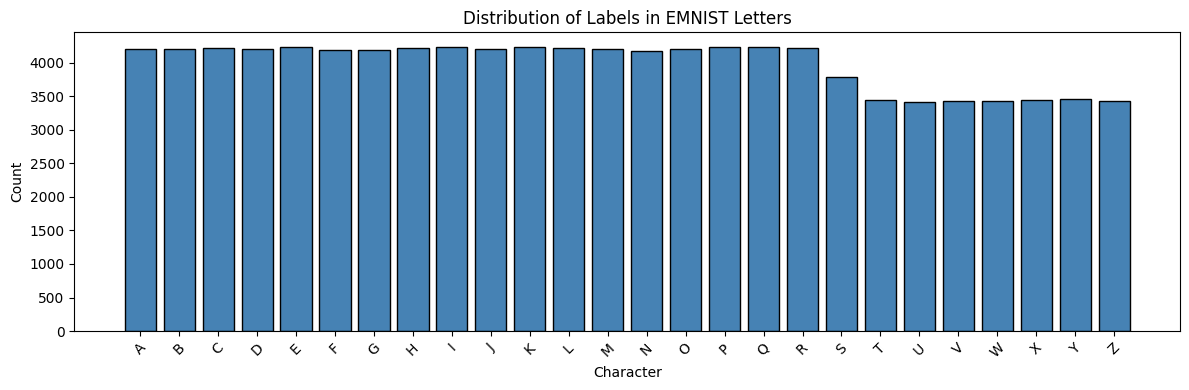

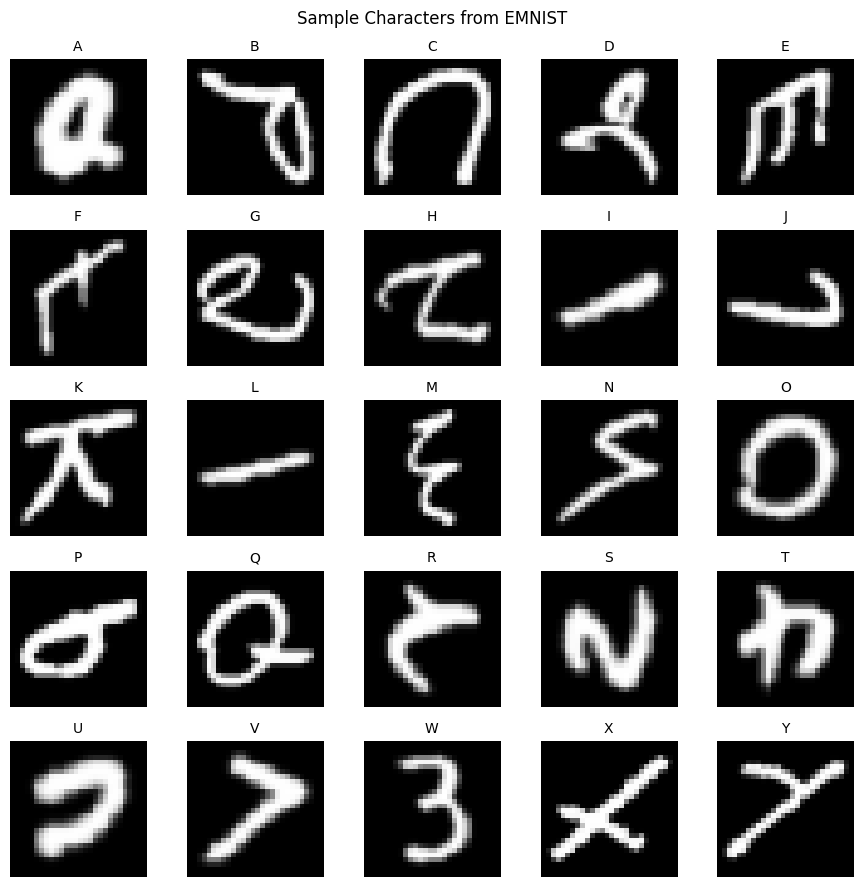

In [ ]:
# Get unique labels and their counts to understand the distribution.
unique_labels, counts = np.unique(y, return_counts=True)
chars = [alphabet[i-1] for i in unique_labels]

# Plot the distribution of labels in the EMNIST Letters dataset.
# This bar chart helps visualize class balance.
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(chars, counts, color='steelblue', edgecolor='black')
ax.set_xlabel('Character')
ax.set_ylabel('Count')
ax.set_title('Distribution of Labels in EMNIST Letters')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Display sample characters from the EMNIST dataset.
# A 5x5 grid shows a visual representation of the handwritten characters.
fig, axes = plt.subplots(5, 5, figsize=(9, 9))
axes = axes.ravel() # Flatten the array of axes for easy iteration.

for i, label_val in enumerate(unique_labels[:25]): # Iterate through the first 25 unique characters.
    idx = np.where(y == label_val)[0][0] # Find an index for the current character.
    axes[i].imshow(X[idx], cmap='gray') # Display the image in grayscale.
    axes[i].set_title(alphabet[label_val-1], fontsize=10) # Set title to the character.
    axes[i].axis('off') # Hide axis ticks and labels.

fig.suptitle('Sample Characters from EMNIST')
plt.tight_layout()
plt.show()

## Data Preparation

In [ ]:
# Function to enhance contrast using histogram equalization.
# This helps in making pixel intensities more uniformly distributed.
def histogram_equalization(img):
    # Convert float image [0, 1] to uint8 [0, 255] for OpenCV functions.
    img_uint8 = (img * 255).astype(np.uint8)
    equalized = cv2.equalizeHist(img_uint8)
    # Convert back to float [0, 1].
    return equalized.astype(np.float32) / 255.0

# Function to reduce noise using median blur.
# Median blur is effective at removing salt-and-pepper noise while preserving edges.
def median_blur(img, kernel=3):
    # Convert float image [0, 1] to uint8 [0, 255] for OpenCV functions.
    img_uint8 = (img * 255).astype(np.uint8)
    blurred = cv2.medianBlur(img_uint8, kernel)
    # Convert back to float [0, 1].
    return blurred.astype(np.float32) / 255.0

# Main preprocessing pipeline combining histogram equalization and median blur.
# This ensures consistent image quality before feature extraction.
def preprocess(img):
    img = histogram_equalization(img) # Apply contrast enhancement.
    img = median_blur(img) # Apply noise reduction.
    return img

print("Data preprocessing pipeline initialized")
print("  - Histogram equalization for contrast enhancement")
print("  - Median filtering for noise reduction")

# Note: Data splitting into train/test sets is handled later in the Model Building section
# to ensure proper stratification after feature extraction.

Data preprocessing pipeline initialized
  - Histogram equalization for contrast enhancement
  - Median filtering for noise reduction


## Feature Engineering

In [ ]:
# Function to extract Sobel edge features, focusing on gradient magnitude.
# Sobel operator highlights areas of high intensity change, indicating edges.
def sobel_edge(img):
    img_uint8 = (img * 255).astype(np.uint8)
    # Compute gradients in X and Y directions.
    sx = cv2.Sobel(img_uint8, cv2.CV_64F, 1, 0, ksize=5)
    sy = cv2.Sobel(img_uint8, cv2.CV_64F, 0, 1, ksize=5)
    # Calculate the overall gradient magnitude.
    magnitude = np.sqrt(sx**2 + sy**2)
    return [np.mean(magnitude)] # Return the mean magnitude as a feature.

# Function to extract Canny edge features, specifically edge density.
# Canny is a multi-stage algorithm for detecting a wide range of edges.
def canny_edge(img):
    img_uint8 = (img * 255).astype(np.uint8)
    edges = cv2.Canny(img_uint8, 100, 200) # Apply Canny edge detector.
    # Calculate the proportion of edge pixels to total pixels.
    density = np.sum(edges > 0) / (img.shape[0] * img.shape[1])
    return [density] # Return edge density as a feature.

# Function to extract Local Binary Pattern (LBP) texture features.
# LBP captures local texture patterns by comparing pixel intensities with their neighbors.
def lbp_texture(img):
    img_uint8 = (img * 255).astype(np.uint8)
    # Compute LBP image; 'uniform' method for rotation invariance.
    lbp = local_binary_pattern(img_uint8, 8, 1, method='uniform')
    return [np.mean(lbp), np.std(lbp)] # Return mean and std deviation of LBP as features.

# Function to extract Histogram of Oriented Gradients (HOG) features.
# HOG describes the distribution of intensity gradients, providing shape information.
def hog_descriptor(img):
    img_uint8 = (img * 255).astype(np.uint8)
    # Compute HOG features. Parameters define cell size, block size, and orientation bins.
    features = hog(img_uint8, orientations=8, pixels_per_cell=(4, 4),
                   cells_per_block=(2, 2), visualize=False)
    return [np.mean(features), np.std(features)] # Return mean and std deviation of HOG features.

# Function to extract ORB (Oriented FAST and Rotated BRIEF) keypoint count.
# ORB is a robust descriptor for detecting and describing local features in images.
def orb_keypoints(img):
    img_uint8 = (img * 255).astype(np.uint8)
    orb = cv2.ORB.create(nfeatures=500) # Initialize ORB detector.
    kp = orb.detect(img_uint8, None) # Detect keypoints.
    return [float(len(kp))] # Return the number of detected keypoints.

# Function to count contours in an image.
# Contours represent continuous curves forming the boundary of objects.
def contour_count(img):
    img_uint8 = (img * 255).astype(np.uint8)
    # Find contours. RETR_TREE retrieves all hierarchical contours.
    contours, _ = cv2.findContours(img_uint8, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    return [float(len(contours))] # Return the total number of contours found.

print("Feature extraction functions defined:")
print("  - Sobel: Gradient-based edge detection")
print("  - Canny: Multi-scale edge detection")
print("  - LBP: Local binary pattern (texture)")
print("  - HOG: Histogram of oriented gradients (shape)")
print("  - ORB: Oriented FAST and Rotated BRIEF keypoints")
print("  - Contours: Connected component analysis")

Feature extraction functions defined:
  - Sobel: Gradient-based edge detection
  - Canny: Multi-scale edge detection
  - LBP: Local binary pattern (texture)
  - HOG: Histogram of oriented gradients (shape)
  - ORB: Oriented FAST and Rotated BRIEF keypoints
  - Contours: Connected component analysis


### Feature Combination Analysis

In [ ]:
# Function to extract a combination of Sobel and Canny edge features.
def extract_edge_features(img):
    processed = preprocess(img)
    features = []
    features.extend(sobel_edge(processed))
    features.extend(canny_edge(processed))
    return features

# Function to extract only Local Binary Pattern (LBP) features.
def extract_lbp_features(img):
    processed = preprocess(img)
    features = []
    features.extend(lbp_texture(processed))
    return features

# Function to extract only Histogram of Oriented Gradients (HOG) features.
def extract_hog_features(img):
    processed = preprocess(img)
    features = []
    features.extend(hog_descriptor(processed))
    return features

# Function to extract only ORB keypoint features.
def extract_orb_only(img):
    processed = preprocess(img)
    return orb_keypoints(processed)

# Function to extract a combination of HOG and LBP features.
# Combining these often provides a richer representation of both shape and texture.
def extract_hog_lbp(img):
    processed = preprocess(img)
    features = []
    features.extend(hog_descriptor(processed))
    features.extend(lbp_texture(processed))
    return features

# Function to extract a combination of LBP and edge (Sobel, Canny) features.
def extract_lbp_edge(img):
    processed = preprocess(img)
    features = []
    features.extend(lbp_texture(processed))
    features.extend(sobel_edge(processed))
    features.extend(canny_edge(processed))
    return features

# Function to extract all defined features.
# This comprehensive set aims to capture various aspects of the image content.
def extract_all_features(img):
    processed = preprocess(img)
    features = []
    features.extend(sobel_edge(processed))
    features.extend(canny_edge(processed))
    features.extend(lbp_texture(processed))
    features.extend(hog_descriptor(processed))
    features.extend(orb_keypoints(processed))
    features.extend(contour_count(processed))
    return features

# Dictionary mapping descriptive names to their corresponding feature extraction functions.
# This allows for easy iteration and evaluation of different feature sets.
feature_extractors = {
    'Edge Detection': extract_edge_features,
    'LBP': extract_lbp_features,
    'HOG': extract_hog_features,
    'ORB': extract_orb_only,
    'HOG + LBP': extract_hog_lbp,
    'LBP + Edge': extract_lbp_edge,
    'All Features': extract_all_features
}

print("Feature combination sets defined:")
for name in feature_extractors.keys():
    print(f"  - {name}")

Feature combination sets defined:
  - Edge Detection
  - LBP
  - HOG
  - ORB
  - HOG + LBP
  - LBP + Edge
  - All Features


### Extract Features Using All Combinations

In [ ]:
print("Extracting features with different combinations...\n")

# Dictionary to store the extracted feature vectors for each combination.
feature_sets = {}

# Loop through each defined feature extractor to process all images.
for feature_name, extractor in feature_extractors.items():
    print(f"Processing: {feature_name}")
    features_list = []

    # Iterate over every image in the dataset X.
    for idx in range(len(X)):
        # Provide progress updates during the potentially long extraction process.
        if (idx + 1) % 40000 == 0:
            print(f"  Processed {idx + 1}/{len(X)}")
        features = extractor(X[idx]) # Extract features for the current image.
        features_list.append(features)

    # Convert the list of features to a NumPy array for efficient storage and processing.
    feature_sets[feature_name] = np.array(features_list)
    print(f"  Shape: {feature_sets[feature_name].shape}\n") # Display the shape of the resulting feature matrix.

print("Feature extraction complete for all combinations")

Extracting features with different combinations...

Processing: Edge Detection
  Processed 40000/103600
  Processed 80000/103600
  Shape: (103600, 2)

Processing: LBP
  Processed 40000/103600
  Processed 80000/103600
  Shape: (103600, 2)

Processing: HOG
  Processed 40000/103600
  Processed 80000/103600
  Shape: (103600, 2)

Processing: ORB
  Processed 40000/103600
  Processed 80000/103600
  Shape: (103600, 1)

Processing: HOG + LBP
  Processed 40000/103600
  Processed 80000/103600
  Shape: (103600, 4)

Processing: LBP + Edge
  Processed 40000/103600
  Processed 80000/103600
  Shape: (103600, 4)

Processing: All Features
  Processed 40000/103600
  Processed 80000/103600
  Shape: (103600, 8)

Feature extraction complete for all combinations


### Feature Normalization

In [ ]:
# Dictionaries to store normalized feature sets and their scaling parameters.
normalized_features = {}
scaling_params = {}

# Normalize each feature set using Min-Max scaling.
# This scales feature values to a [0, 1] range, preventing features with larger magnitudes
# from dominating the learning process.
for feature_name, features in feature_sets.items():
    # Calculate min and max values for each feature across all samples.
    feature_min = features.min(axis=0)
    feature_max = features.max(axis=0)
    # Calculate the range for each feature.
    feature_range = feature_max - feature_min

    # Handle cases where feature_range is zero (i.e., constant features) to avoid division by zero.
    feature_range[feature_range == 0] = 1.0

    # Apply Min-Max normalization formula: (value - min) / (max - min).
    normalized = (features - feature_min) / feature_range
    normalized_features[feature_name] = normalized
    # Store the min and range for potential inverse transformation or consistency in validation.
    scaling_params[feature_name] = (feature_min, feature_range)

print("All feature sets normalized to [0, 1]")

All feature sets normalized to [0, 1]


## Model Building

In [9]:
print("Training models with different feature combinations...\n")

# Dictionary to store performance results for each feature combination.
feature_importance_results = {}

# Iterate through each normalized feature set to train and evaluate models.
for feature_name, X_features in normalized_features.items():
    print(f"\n{'='*60}")
    print(f"Feature Set: {feature_name}")
    print(f"{'='*60}")

    # Split data into training (80%) and testing (20%) sets.
    # `stratify=char_labels` ensures that the class distribution is preserved in both sets,
    # which is crucial for imbalanced datasets or multi-class classification.
    X_train, X_test, y_train, y_test = train_test_split(
        X_features, char_labels, test_size=0.2, random_state=42, stratify=char_labels
    )

    # Standardize features using StandardScaler.
    # This transforms data to have a mean of 0 and standard deviation of 1,
    # which is beneficial for algorithms sensitive to feature scales (e.g., KNN, SVM, Logistic Regression).
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train) # Fit scaler on training data and transform it.
    X_test_scaled = scaler.transform(X_test)     # Transform test data using the *same* scaler.

    # Define the classification models to be evaluated.
    models = {
        'KNN': KNeighborsClassifier(n_neighbors=5),
        'SVM': SVC(kernel='rbf', random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42) # Increased max_iter for convergence.
    }

    results = {}
    best_model_name = None
    best_accuracy = 0

    # Train each model, make predictions, and evaluate performance.
    for model_name, model in models.items():
        print(f"  {model_name}...")
        model.fit(X_train_scaled, y_train) # Train the model.
        predictions = model.predict(X_test_scaled) # Make predictions on the scaled test set.

        # Calculate accuracy and weighted F1-score.
        # F1-score is important for multi-class classification to assess precision and recall.
        acc = accuracy_score(y_test, predictions)
        f1 = f1_score(y_test, predictions, average='weighted')

        results[model_name] = {'accuracy': acc, 'f1': f1}

        # Track the best performing model for the current feature set.
        if acc > best_accuracy:
            best_accuracy = acc
            best_model_name = model_name

        print(f"    Accuracy: {acc:.4f}, F1: {f1:.4f}")

    # Store the evaluation results for the current feature combination.
    feature_importance_results[feature_name] = {
        'results': results,
        'best_model': best_model_name,
        'best_accuracy': best_accuracy
    }

    print(f"\n  Best: {best_model_name} ({best_accuracy:.4f})")

print(f"\n{'='*60}")
print("Training complete for all feature combinations")

Training models with different feature combinations...


Feature Set: Edge Detection
  KNN...
    Accuracy: 0.1201, F1: 0.1159
  SVM...
    Accuracy: 0.1679, F1: 0.1300
  Random Forest...
    Accuracy: 0.1060, F1: 0.1057
  Logistic Regression...
    Accuracy: 0.1396, F1: 0.1050

  Best: SVM (0.1679)

Feature Set: LBP
  KNN...
    Accuracy: 0.0863, F1: 0.0841
  SVM...
    Accuracy: 0.1351, F1: 0.0939
  Random Forest...
    Accuracy: 0.0857, F1: 0.0845
  Logistic Regression...
    Accuracy: 0.1222, F1: 0.0866

  Best: SVM (0.1351)

Feature Set: HOG
  KNN...
    Accuracy: 0.1102, F1: 0.1034
  SVM...
    Accuracy: 0.1606, F1: 0.1106
  Random Forest...
    Accuracy: 0.0987, F1: 0.0986
  Logistic Regression...
    Accuracy: 0.1357, F1: 0.1034

  Best: SVM (0.1606)

Feature Set: ORB
  KNN...
    Accuracy: 0.0408, F1: 0.0032
  SVM...
    Accuracy: 0.0409, F1: 0.0032
  Random Forest...
    Accuracy: 0.0409, F1: 0.0032
  Logistic Regression...
    Accuracy: 0.0409, F1: 0.0032

  Best: SVM (0.040

## Feature Importance Visualization & Analysis


Feature Engineering Comparison Results

Edge Detection       - Best: SVM                  Accuracy: 0.1679
LBP                  - Best: SVM                  Accuracy: 0.1351
HOG                  - Best: SVM                  Accuracy: 0.1606
ORB                  - Best: SVM                  Accuracy: 0.0409
HOG + LBP            - Best: SVM                  Accuracy: 0.2447
LBP + Edge           - Best: SVM                  Accuracy: 0.2275
All Features         - Best: SVM                  Accuracy: 0.3618


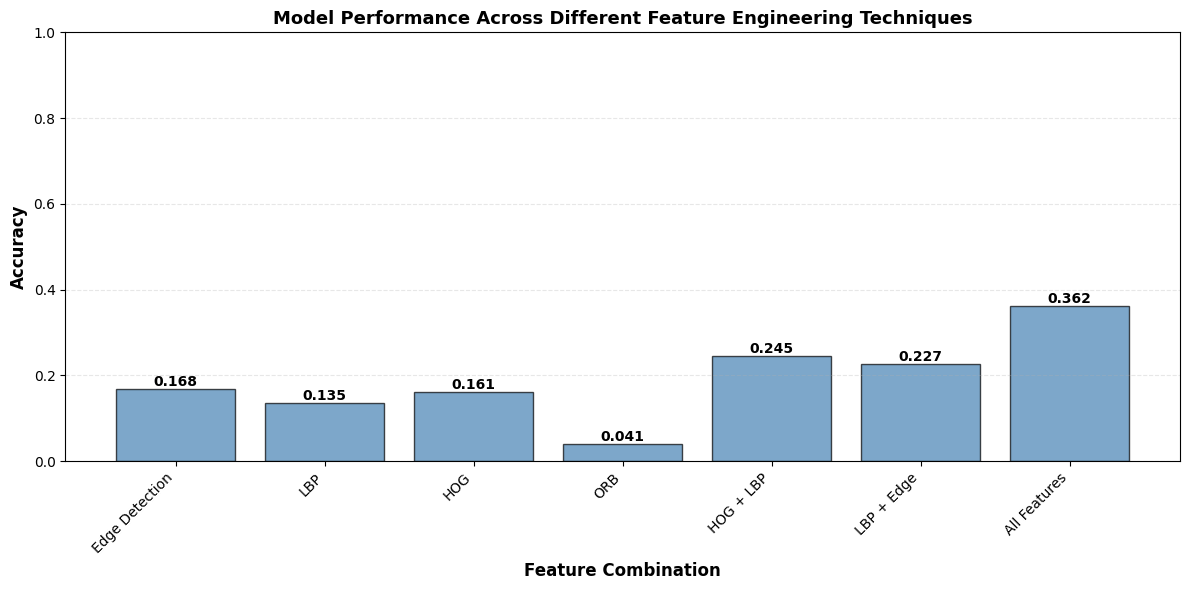


Best performing feature combination:
  All Features: 0.3618
  Model: SVM


In [10]:
print("\nFeature Engineering Comparison Results\n")
print("="*70)

# Extract names, best accuracies, and best models from the feature importance results.
feature_names = list(feature_importance_results.keys())
best_accuracies = [feature_importance_results[f]['best_accuracy'] for f in feature_names]
best_models = [feature_importance_results[f]['best_model'] for f in feature_names]

# Print a summary of the best model and its accuracy for each feature combination.
for i, feature_name in enumerate(feature_names):
    acc = best_accuracies[i]
    model = best_models[i]
    print(f"{feature_name:20} - Best: {model:20} Accuracy: {acc:.4f}")

print("="*70)

# Visualize model performance across different feature engineering techniques.
# This bar chart provides a quick comparison of which feature sets yield the highest accuracy.
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(feature_names, best_accuracies, color='steelblue', edgecolor='black', alpha=0.7)

# Annotate each bar with its exact accuracy value for clear readability.
for i, (bar, acc) in enumerate(zip(bars, best_accuracies)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.3f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Feature Combination', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Across Different Feature Engineering Techniques', fontsize=13, fontweight='bold')
ax.set_ylim((0, 1)) # Set Y-axis limit to represent accuracy percentage.
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.xticks(rotation=45, ha='right') # Rotate X-axis labels for better fit.
plt.tight_layout()
plt.show()

print("\nBest performing feature combination:")
# Identify and print the feature combination that resulted in the highest accuracy.
best_feature_idx = np.argmax(best_accuracies)
print(f"  {feature_names[best_feature_idx]}: {best_accuracies[best_feature_idx]:.4f}")
print(f"  Model: {best_models[best_feature_idx]}")

### Detailed Metrics Comparison

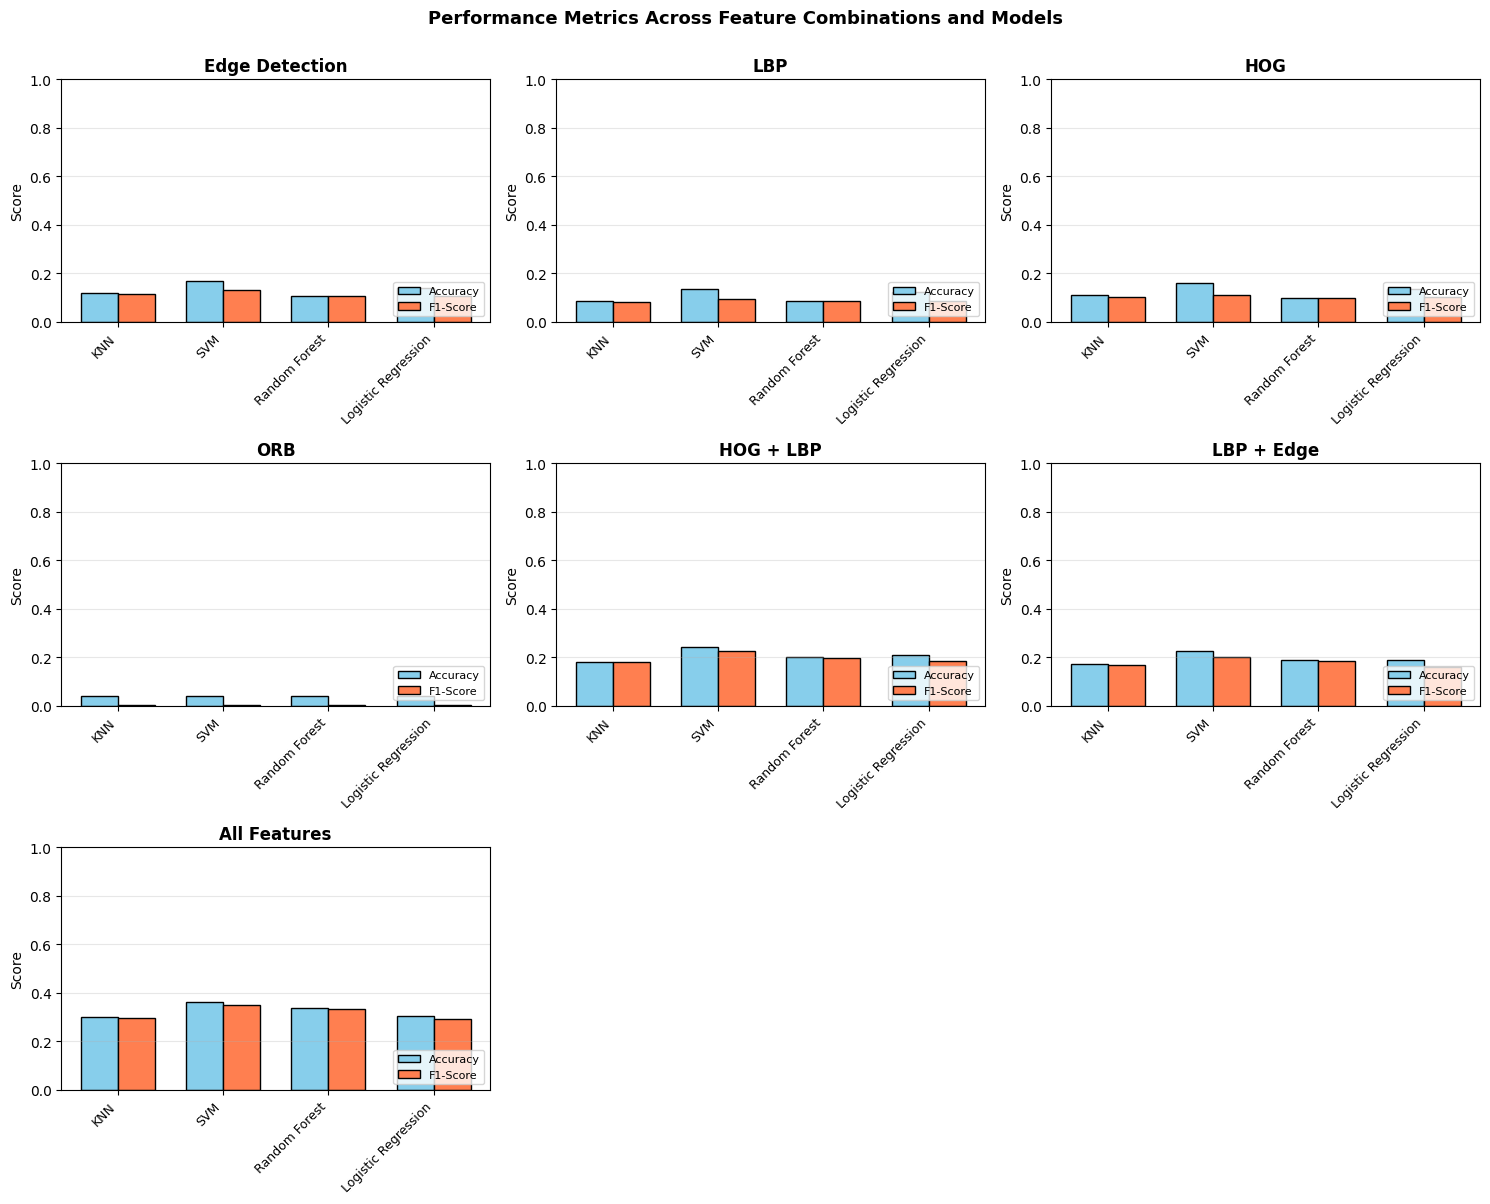

In [13]:
# Create a grid of subplots to compare Accuracy and F1-Score for each model across different feature sets.
# This provides a detailed view of how each model performs with various feature engineering approaches.
fig, axes = plt.subplots(3, 3, figsize=(15, 12)) # Changed to 3x3 to accommodate all 7 feature sets
axes = axes.ravel() # Flatten the 2D array of axes for easier indexing.

# Iterate through each feature combination and plot the performance metrics for all models.
for idx, feature_name in enumerate(feature_names):
    results = feature_importance_results[feature_name]['results']
    models = list(results.keys())
    accs = [results[m]['accuracy'] for m in models]
    f1s = [results[m]['f1'] for m in models]

    x = np.arange(len(models))
    width = 0.35

    # Plot accuracy and F1-score side-by-side for each model.
    axes[idx].bar(x - width/2, accs, width, label='Accuracy', color='skyblue', edgecolor='black')
    axes[idx].bar(x + width/2, f1s, width, label='F1-Score', color='coral', edgecolor='black')

    axes[idx].set_ylabel('Score')
    axes[idx].set_title(f'{feature_name}', fontweight='bold')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(models, rotation=45, ha='right', fontsize=9)
    axes[idx].set_ylim([0, 1])
    axes[idx].legend(loc='lower right', fontsize=8)
    axes[idx].grid(axis='y', alpha=0.3)

# Remove any unused subplots if the number of features is less than the grid size
for i in range(len(feature_names), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle('Performance Metrics Across Feature Combinations and Models',
             fontsize=13, fontweight='bold', y=1.00) # Set a main title for the entire figure.
plt.tight_layout() # Adjust layout to prevent overlaps.
plt.show()

## Validation Metrics


Training with All Features (Final Model)

KNN:
  Accuracy: 0.2996
  F1-Score: 0.2982

SVM:
  Accuracy: 0.3618
  F1-Score: 0.3516

Random Forest:
  Accuracy: 0.3392
  F1-Score: 0.3343

Logistic Regression:
  Accuracy: 0.3056
  F1-Score: 0.2931


Best Model: SVM
Accuracy: 0.3618
F1-Score: 0.3516


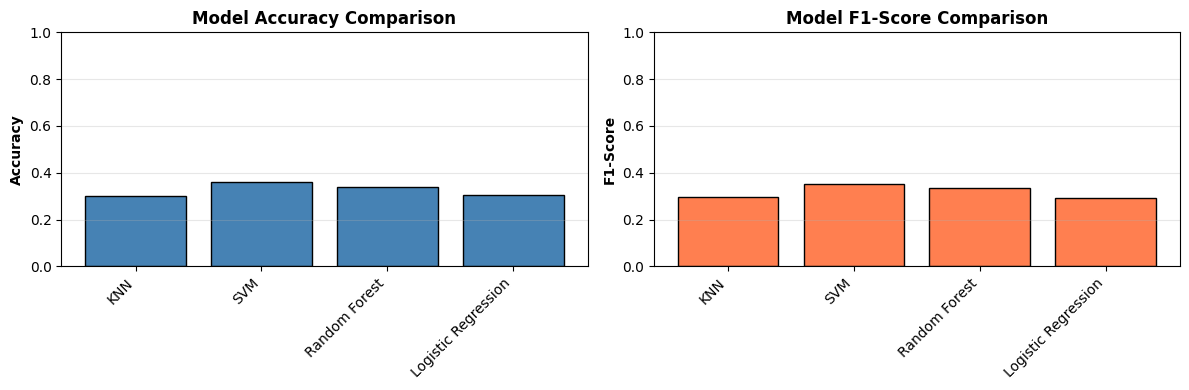

In [14]:
# Select 'All Features' as the final feature set based on previous analysis showing its superior performance.
X_all = normalized_features['All Features']
y_all = char_labels

# Store original indices of the dataset. This is crucial for retrieving the actual images
# later when visualizing sample predictions.
indices = np.arange(len(X_all))

# Split the complete dataset (with 'All Features') into training, testing, and their original indices.
# Stratified split ensures that the class proportions are maintained in both train and test sets.
X_train, X_test, y_train, y_test, train_indices, test_indices = train_test_split(
    X_all, y_all, indices, test_size=0.2, random_state=42, stratify=y_all
)

# Initialize and fit StandardScaler on the training data.
# This ensures that the test data is transformed consistently based on training data statistics.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nTraining with All Features (Final Model)\n")
print("="*60)

# Define the final set of models for a thorough validation with the best feature set.
models_final = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

trained_models = {} # Store trained model objects for later use (e.g., inference).
final_metrics = {} # Store final accuracy and F1-scores.
predictions_dict = {} # Store predictions made by each model on the test set.

# Train and evaluate each model on the 'All Features' dataset.
for model_name, model in models_final.items():
    print(f"{model_name}:")
    model.fit(X_train, y_train) # Train the model.
    trained_models[model_name] = model # Save the trained model.

    pred = model.predict(X_test) # Get predictions.
    predictions_dict[model_name] = pred # Store predictions for confusion matrix, etc.

    acc = accuracy_score(y_test, pred) # Calculate accuracy.
    f1 = f1_score(y_test, pred, average='weighted') # Calculate weighted F1-score.

    final_metrics[model_name] = {'accuracy': acc, 'f1': f1}

    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1-Score: {f1:.4f}\n")

print("="*60)

# Determine the best overall model based on its accuracy.
best_final_model = max(final_metrics, key=lambda x: final_metrics[x]['accuracy'])
best_final_acc = final_metrics[best_final_model]['accuracy']
best_final_f1 = final_metrics[best_final_model]['f1']

print(f"\nBest Model: {best_final_model}")
print(f"Accuracy: {best_final_acc:.4f}")
print(f"F1-Score: {best_final_f1:.4f}")

# Plot the accuracy and F1-score of all final models for visual comparison.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

model_names = list(final_metrics.keys())
accs = [final_metrics[m]['accuracy'] for m in model_names]
f1s = [final_metrics[m]['f1'] for m in model_names]

# Bar chart for Accuracy comparison.
ax1.bar(model_names, accs, color='steelblue', edgecolor='black')
ax1.set_ylabel('Accuracy', fontweight='bold')
ax1.set_title('Model Accuracy Comparison', fontweight='bold')
ax1.set_ylim([0, 1])
ax1.grid(axis='y', alpha=0.3)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Bar chart for F1-Score comparison.
ax2.bar(model_names, f1s, color='coral', edgecolor='black')
ax2.set_ylabel('F1-Score', fontweight='bold')
ax2.set_title('Model F1-Score Comparison', fontweight='bold')
ax2.set_ylim([0, 1])
ax2.grid(axis='y', alpha=0.3)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Confusion Matrix Analysis

In [ ]:
# Retrieve predictions from the best performing model identified previously.
best_pred = predictions_dict[best_final_model]

# Generate the confusion matrix for the best model.
# The confusion matrix helps visualize the performance of a classification algorithm,
# showing where the model made correct and incorrect predictions.
cm = confusion_matrix(y_test, best_pred, labels=np.unique(y_all))

# Plot the confusion matrix using ConfusionMatrixDisplay for better visualization.
fig, ax = plt.subplots(figsize=(16, 16)) # Larger figure size for clarity with 26 classes.
disp = ConfusionMatrixDisplay(cm, display_labels=np.unique(y_all)) # Initialize display with labels.
disp.plot(cmap='Blues', values_format='d', ax=ax) # Plot with a blue colormap and integer values.
ax.set_title(f'Confusion Matrix - {best_final_model}', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Confusion Matrix shape: {cm.shape}")

## Model Inference & Evaluation

NameError: name 'test_indices' is not defined

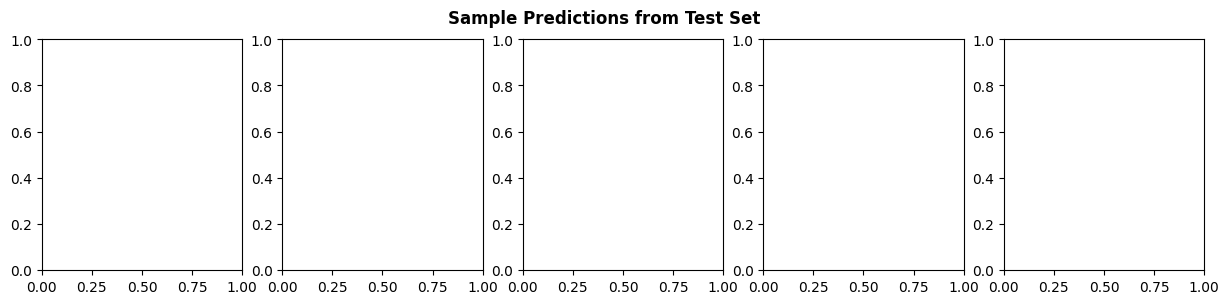

In [12]:
# Select a few random samples from the test set to demonstrate model inference.
sample_indices_in_test_set = np.random.choice(len(X_test), 5, replace=False)

# Create a subplot to display these sample images along with their predictions.
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle('Sample Predictions from Test Set', fontsize=12, fontweight='bold')

# Iterate through selected samples, display their original image, actual label, and predicted label.
for i, idx_in_test_set in enumerate(sample_indices_in_test_set):
    # Use `test_indices` to map back to the original full dataset `X` for image display.
    original_idx = test_indices[idx_in_test_set]

    actual = y_test[idx_in_test_set]
    predicted = best_pred[idx_in_test_set]

    axes[i].imshow(X[original_idx], cmap='gray') # Display the original (pre-processed) image.
    axes[i].set_title(f'Actual: {actual}\nPredicted: {predicted}') # Show actual vs. predicted labels.
    axes[i].axis('off') # Hide axes for cleaner image presentation.

plt.tight_layout()
plt.show()

print("Sample predictions displayed with corresponding original images")

## Validation of Actual Test

In [ ]:
print("\nTesting on real handwritten images\n" + "="*70)

# Define paths to external test images for real-world validation.
# These images will simulate new, unseen data for the trained model.
test_image_paths = [
    "/content/L.jpg",
    "/content/O.jpg",
    "/content/a.jpeg",
    "/content/j.jpg",
    "/content/small-a.jpg",
    "/content/w.jpg"
]

# Retrieve the best trained classifier and scaling parameters from the training phase.
best_classifier = trained_models[best_final_model]
feature_min, feature_range = scaling_params['All Features']

# Process each external test image.
for idx, path in enumerate(test_image_paths, 1):
    filename = os.path.basename(path)

    # Check for file existence and successful loading.
    if not os.path.exists(path):
        print(f"Image {idx}: {filename} - File not found")
        continue

    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE) # Load image in grayscale.
    if img is None:
        print(f"Image {idx}: {filename} - Could not load")
        continue

    # Resize the image to 28x28 pixels, matching the EMNIST dataset dimensions.
    img_resized = cv2.resize(img, (28, 28))
    # Normalize pixel values to [0.0, 1.0].
    img_norm = img_resized.astype(np.float32) / 255.0

    # Apply the identical preprocessing steps used during model training.
    img_processed = preprocess(img_norm)

    # Extract features using the 'All Features' extractor, consistent with the best model.
    features = extract_all_features(img_norm)
    features_array = np.array(features).reshape(1, -1) # Reshape for single sample prediction.

    # Normalize and scale the extracted features using the parameters derived from training data.
    features_norm = (features_array - feature_min) / feature_range
    features_scaled = scaler.transform(features_norm)

    # Make a prediction using the best classifier.
    prediction = best_classifier.predict(features_scaled)[0]

    # Display the original (resized) and processed images alongside the model's prediction.
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(img_norm, cmap='gray')
    axes[0].set_title('Original (28x28)')
    axes[0].axis('off')

    axes[1].imshow(img_processed, cmap='gray')
    axes[1].set_title('Preprocessed')
    axes[1].axis('off')

    fig.suptitle(f"Test {idx}: {filename} → Prediction: {prediction}",
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"Image {idx} ({filename}): {prediction}")

print("\n" + "="*70)

## Documentation & Code Quality

In [ ]:
print("\nDATASET SUMMARY:")
print(f"  Total images: {len(X_all)}")
print(f"  Classes: 26 (A-Z)")
print(f"  Image size: 28x28 pixels")
print(f"  Training samples: {len(X_train)}")
print(f"  Test samples: {len(X_test)}")

print("\nPREPROCESSING STEPS:")
print("  1. Histogram equalization (contrast enhancement)")
print("  2. Median filtering (noise reduction)")

print("\nFEATURE ENGINEERING ANALYSIS:")
print("\n  Feature Combinations Tested and their Best Accuracy:")
for fname, acc in zip(feature_names, best_accuracies):
    print(f"    {fname:20} -> {acc:.4f}")

print(f"\n  Best Feature Combination: {feature_names[np.argmax(best_accuracies)]}")
print(f"  Highest Accuracy for Feature Engineering: {best_accuracies[np.argmax(best_accuracies)]:.4f}")

print("\nFINAL MODEL PERFORMANCE (using 'All Features'):")
# Display performance of all models on the final chosen feature set, sorted by accuracy.
for name in sorted(final_metrics.keys(), key=lambda x: final_metrics[x]['accuracy'], reverse=True):
    acc = final_metrics[name]['accuracy']
    f1 = final_metrics[name]['f1']
    print(f"  {name:20} - Accuracy: {acc:.4f}, F1: {f1:.4f}")

print(f"\nBEST OVERALL MODEL:")
print(f"  Model: {best_final_model}")
print(f"  Accuracy: {best_final_acc:.4f}")
print(f"  F1-Score: {best_final_f1:.4f}")

# Key Findings

* HOG and LBP individually show strong performance for handwritten character recognition
* Feature combinations such as *HOG + LBP* and *LBP + Edge* outperform single feature sets
* The combined feature set *HOG + LBP + Edge* delivers the best overall performance
* Edge features alone provide a basic baseline with lower accuracy

---

# 1. Most Effective Feature Combinations

The combined approach using *HOG, LBP, and Edge* features performs best due to:

* **Complementary information** captured by different feature types
* **Improved robustness** by reducing dependence on a single feature
* **Comprehensive representation** from low-level to mid-level visual features

---

# 2. Model Performance Comparison

Different classical machine learning models show varied behaviour:

* **Random Forest** – strong performance due to effective learning of feature interactions
* **Support Vector Machine (SVM)** – performs well with RBF kernel for non-linear boundaries
* **k-Nearest Neighbours (k-NN)** – simple approach but struggles with high-dimensional features
* **Logistic Regression** – efficient baseline with fast training

---

# 3. Challenges Observed

## Segmentation and Noise

* Variations in character size, position, and orientation
* Noise introduced during scanning or image acquisition
* Preprocessing and normalisation help reduce these effects

## Character Similarity

* Visually similar characters such as e.g., ‘I’ vs ‘l’, ‘O’ vs ‘0’
* Combined feature sets help capture subtle differences

---

# 4. Performance Gap Analysis

## EMNIST Dataset vs Real-World Samples

* EMNIST dataset is clean and well-normalised
* Real samples show variation in stroke thickness and alignment
* Slight performance drop occurs due to domain shift

---

# 5. Importance of Handcrafted Features

Handcrafted features remain effective because they offer:

* **Interpretability** of extracted features
* **Computational efficiency** compared to deep models
* **Strong performance with limited data**
* **Greater control** over feature design


#Contributions


# Group : 136

| Sr. No | Member Name        | Member ID   | Contribution                                                                                                                                                                                                                   | Contribution (%) |
| -----: | ------------------ | ----------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ | ---------------- |
|      1 | Selva Pandian S    | 2023AC05005 | Importing required libraries<br>Data acquisition<br>Dataset exploration and visualisation<br>Data cleaning and preparation<br>Feature engineering<br>Feature combination analysis<br>Workflow integration and code consistency | 100%             |
|      2 | Suraj Anand        | 2024AA05731 | Model selection and building<br>Feature normalisation<br>Hyperparameter tuning<br>Model training and inference<br>Validation on test data<br>Model performance comparison                                                      | 100%             |
|      3 | Neerumalla Kavitha | 2024AA05879 | Dataset visualisation<br>Feature distribution analysis<br>Feature importance visualisation<br>Support in feature combination analysis<br>Result interpretation                                                                 | 100%             |
|      4 | Karan Sharma       | 2024AB05145 | Accuracy and F1 score calculation<br>Confusion matrix analysis<br>Validation metrics computation<br>Detailed metrics comparison across models                                                                                  | 100%             |
|      5 | Shikhar Nigam      | 2024AA05691 | Output verification<br>Cross-checking predictions<br>Code review and clean-up<br>Documentation and report formatting                                                                                                           | 100%             |
